In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from castle.algorithms import Notears
from sklearn.linear_model import LogisticRegression

#LiNGAM algorithm for causal discovery (Optional, not required for boolean target)
from lingam import DirectLiNGAM
from lingam.utils import make_dot

# Show all columns regardless of how many there are
pd.set_option('display.max_columns', None)
# Increase the width of the display area
pd.set_option('display.width', 2000)
# Optional: suppress scientific notation for clearer causal weights
pd.set_option('display.float_format', lambda x: '%.4f' % x)

def display_df(df):
  styled_df = df.style.format("{:.3f}").set_table_styles([
    {'selector': 'th', 'props': [('white-space', 'nowrap')]},
    {'selector': 'td', 'props': [('white-space', 'nowrap')]}
  ])

  display(styled_df)

In [39]:

############################################
# 1️⃣ Load Data
############################################
target = "Defect"
col_names_df = pd.read_csv("nasa_kaggle_col_mapping.csv")
col_name_dict = dict(zip(col_names_df["original"].values, col_names_df["short_name"].values))

df = pd.read_csv("cm1.csv").rename(columns=col_name_dict)

print(df.head(5))
df["Defect"] = df["Defect"]*1
print(df.head(5))

print(df["Defect"].sum(), len(df["Defect"]))

# Drop identifier
if "id" in df.columns:
    df = df.drop(columns=["id"])

df["Defect"] = df["Defect"].fillna(0)
df["Size"] = df[["CodeLOC","HalLOC","ComLOC"]].mean(axis=1)
df["McCabe"] = df[["CycComp","EssComp","DesComp"]].mean(axis=1)
df["HalStruct"] = df[["UniqOp","UniqOpr"]].mean(axis=1)
df["HalCog"] = df[["HalDiff","HalEff"]].mean(axis=1)

df = df[["Size","McCabe","HalStruct","HalCog","Defect"]]

print(df.columns)

   id  CodeLOC  CycComp  EssComp  DesComp  HalTok   HalVol  HalLen  HalDiff  HalIntel    HalEff  HalTime        t  HalLOC  ComLOC  BlankLOC  locCodeAndComment  UniqOp  UniqOpr   TotOp  TotOpr  Branches  Defect
0   1   1.1000   1.4000   1.4000   1.4000  1.3000   1.3000  1.3000   1.3000    1.3000    1.3000   1.3000   1.3000       2       2         2                  2  1.2000   1.2000  1.2000  1.2000    1.4000   False
1   2   1.0000   1.0000   1.0000   1.0000  1.0000   1.0000  1.0000   1.0000    1.0000    1.0000   1.0000   1.0000       1       1         1                  1  1.0000   1.0000  1.0000  1.0000    1.0000    True
2   3  24.0000   5.0000   1.0000   3.0000 63.0000 309.1300  0.1100   9.5000   32.5400 2936.7700   0.1000 163.1500       1       0         6                  0 15.0000  15.0000 44.0000 19.0000    9.0000   False
3   4  20.0000   4.0000   4.0000   2.0000 47.0000 215.4900  0.0600  16.0000   13.4700 3447.8900   0.0700 191.5500       0       0         3                  0 1

In [40]:
#################################################################
# 2. Notears causal discovery on other features other than target
#################################################################

predictors = [c for c in df.columns if c != target]
X_pred = StandardScaler().fit_transform(df[predictors].values)

d = len(predictors)

# Create index lookup
idx = {name: i for i, name in enumerate(predictors)}

size_idx = idx["Size"]
mccabe_idx = idx["McCabe"]

# --------------------------------------------------
# 2. Create prior knowledge matrix
# --------------------------------------------------
# In CASTLE:
#   -1  -> unknown (free to learn)
#    0  -> forbidden edge
#    1  -> required edge

prior = -1 * np.ones((d, d))

# No self-loops
np.fill_diagonal(prior, 0)

# Enforce business rule:
# Forbid McCabe → Size
prior[mccabe_idx, size_idx] = 0

# Allow Size → McCabe
prior[size_idx, mccabe_idx] = 1

# --------------------------------------------------
# 3. Train NOTEARS with prior knowledge
# --------------------------------------------------

model = Notears(lambda1=0.01)

model.learn(X_pred, prior_knowledge=prior)

W_pred = model.causal_matrix
print(np.round(W_pred, 3))

2026-03-07 11:48:08,922 - C:\Users\singhn8\AppData\Local\anaconda3\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:195] - INFO: [start]: n=498, d=4, iter_=100, h_=1e-08, rho_=1e+16
2026-03-07 11:48:08,946 - C:\Users\singhn8\AppData\Local\anaconda3\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 0] h=1.236e-01, loss=2.000, rho=1.0e+00
2026-03-07 11:48:08,987 - C:\Users\singhn8\AppData\Local\anaconda3\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=1.014e-01, loss=0.350, rho=1.0e+00
2026-03-07 11:48:09,023 - C:\Users\singhn8\AppData\Local\anaconda3\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=5.578e-02, loss=0.419, rho=1.0e+01
2026-03-07 11:48:09,066 - C:\Users\singhn8\AppData\Local\anaconda3\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=2.099e-02, loss=1.106, rho=1.0e+02
2026-03-07 11:48:09,096

[[0 1 1 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]]


In [44]:
#####################################################################
# 3. Logistic regression on target, and use the coefficients for edges
#####################################################################

logit = LogisticRegression(max_iter=500)
logit.fit(df[predictors], df["Defect"])

coef = pd.Series(logit.coef_[0], index=predictors)
important = coef[coef.abs() > 0.04]  # adjust threshold

In [45]:
import networkx as nx

G = nx.DiGraph()

# Add predictor structure
threshold = 0.01

for i in range(len(predictors)):
    for j in range(len(predictors)):
        if abs(W_pred[i, j]) > threshold:
            G.add_edge(predictors[i], predictors[j])

# Add causal edges into Defect
for var in important.index:
    G.add_edge(var, "Defect")

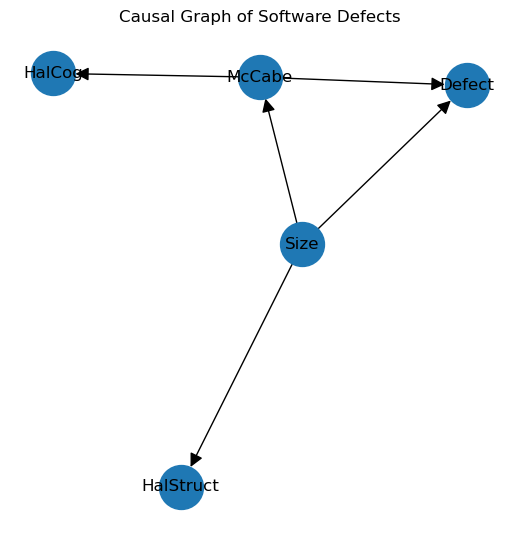

In [46]:
plt.figure(figsize=(5,5))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos,
        with_labels=True,
        node_size=1000,
        arrows=True,
        arrowsize=20)

plt.title("Causal Graph of Software Defects")
plt.axis("off")
plt.show()